In [1]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold, LeaveOneOut
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Optional visualization imports
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_VIZ = True
    plt.style.use('seaborn-v0_8-darkgrid')
except ImportError:
    HAS_VIZ = False
    print("⚠️  matplotlib/seaborn not available - visualization disabled")

print("✓ Imports successful")


✓ Imports successful


In [2]:
# ============================================================================
# CELL 2: LOAD DATA — 4 seasons (train:3, test:1) from allseasons CSV
# TARGET toggle: set USE_NORMALIZED_TARGET = True to use bypasses/possession
# ============================================================================
print("=" * 80)
print("CELL 2: DATA LOADING")
print("=" * 80)

USE_NORMALIZED_TARGET = True   # <-- toggle: True = bypasses/possession, False = raw count

TRAIN_SEASONS = ['2012/2013', '2013/2014', '2014/2015']
TEST_SEASON   = '2015/2016'

df_all = pd.read_csv(Path("../data/processed/Barcelona_allseasons_features.csv"))
df = df_all[df_all['season'].isin(TRAIN_SEASONS + [TEST_SEASON])].copy().reset_index(drop=True)

# ── Normalize bypass count by opponent possessions per half ──────────────────
import json as _json, glob as _glob
from collections import defaultdict

BARCA_ID = 217
poss_rows = []
for fpath in sorted(_glob.glob('../data/raw/events/Barcelona_*/*.json')):
    from pathlib import Path as _P
    mid = _P(fpath).stem
    with open(fpath) as _f:
        events = _json.load(_f)
    opp_poss = defaultdict(set)
    for ev in events:
        pt = ev.get('possession_team', {})
        if isinstance(pt, dict) and pt.get('id') != BARCA_ID:
            period = ev.get('period', 1)
            poss_id = ev.get('possession')
            if poss_id is not None and period in (1, 2):
                opp_poss[period].add(poss_id)
    for period in (1, 2):
        poss_rows.append({'match_id': f'{mid}_P{period}', 'total_opp_possessions': len(opp_poss[period])})

poss_df = pd.DataFrame(poss_rows)
df = df.merge(poss_df, on='match_id', how='left')
df['total_opp_possessions'] = df['total_opp_possessions'].fillna(df['total_opp_possessions'].median())
df['bypasses_per_possession'] = df['bypasses_per_halftime'] / df['total_opp_possessions']

# ── Feature list ──────────────────────────────────────────────────────────────
feat_list_path = Path("../data/processed/Barcelona_2014_2015_selected_features_list.txt")
feature_cols = [l.strip() for l in feat_list_path.read_text().splitlines() if l.strip()]
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

X = df[feature_cols].copy()
TARGET_COL = 'bypasses_per_possession' if USE_NORMALIZED_TARGET else 'bypasses_per_halftime'
y = df[TARGET_COL].copy()

print(f"Target         : {TARGET_COL}  (normalized={USE_NORMALIZED_TARGET})")
print(f"Seasons used   : {TRAIN_SEASONS} (train) + [{TEST_SEASON}] (test)")
print(f"Total rows     : {len(df)}  ({df['match_id'].nunique()} match-halves)")
print(f"Feature matrix : {X.shape}")
print(f"Target stats   : mean={y.mean():.4f}, std={y.std():.4f}, range=[{y.min():.4f},{y.max():.4f}]")
if USE_NORMALIZED_TARGET:
    print(f"Opp possessions: mean={df['total_opp_possessions'].mean():.1f}, "
          f"std={df['total_opp_possessions'].std():.1f}, range=[{df['total_opp_possessions'].min():.0f},{df['total_opp_possessions'].max():.0f}]")


CELL 2: DATA LOADING


Target         : bypasses_per_possession  (normalized=True)
Seasons used   : ['2012/2013', '2013/2014', '2014/2015'] (train) + [2015/2016] (test)
Total rows     : 842  (280 match-halves)
Feature matrix : (842, 15)
Target stats   : mean=0.1726, std=0.0666, range=[0.0256,0.4000]
Opp possessions: mean=43.2, std=6.2, range=[30,63]


In [3]:
# ============================================================================
# CELL 3: TRAIN/TEST SPLIT — temporal (3 seasons train, 1 season test)
# Scaler is fit on TRAIN only to avoid data leakage.
# ============================================================================
print("=" * 80)
print("CELL 3: TRAIN/TEST SPLIT (Temporal, no leakage scaling)")
print("=" * 80)

train_mask = df['season'].isin(TRAIN_SEASONS)
test_mask  = df['season'] == TEST_SEASON

X_train_raw = X[train_mask].reset_index(drop=True)
X_test_raw  = X[test_mask].reset_index(drop=True)
y_train     = y[train_mask].reset_index(drop=True)
y_test      = y[test_mask].reset_index(drop=True)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=feature_cols)

print(f"Train: {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)  —  {TRAIN_SEASONS}")
print(f"Test : {len(X_test)} rows ({len(X_test)/len(X)*100:.1f}%)  —  [{TEST_SEASON}]")
print(f"Training target : mean={y_train.mean():.2f}, std={y_train.std():.2f}, range=[{y_train.min():.0f},{y_train.max():.0f}]")
print(f"Test target     : mean={y_test.mean():.2f}, std={y_test.std():.2f}, range=[{y_test.min():.0f},{y_test.max():.0f}]")
print("Scaler fit on training data only — no future leakage.")


CELL 3: TRAIN/TEST SPLIT (Temporal, no leakage scaling)
Train: 614 rows (72.9%)  —  ['2012/2013', '2013/2014', '2014/2015']
Test : 228 rows (27.1%)  —  [2015/2016]
Training target : mean=0.18, std=0.06, range=[0,0]
Test target     : mean=0.16, std=0.07, range=[0,0]
Scaler fit on training data only — no future leakage.


In [4]:
# ============================================================================
# CELL 4: TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ============================================================================
print("=" * 80)
print("CELL 4: TRAINING MLR MODEL")
print("=" * 80)

# Initialize and train the model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

print(f"\nModel trained: MLR")
print(f"Intercept: {mlr_model.intercept_:.4f}, Coefficients: {len(mlr_model.coef_)}")

# Display top coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': mlr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nTop 5 coefficients:")
print(coef_df.head(5).to_string(index=False))


CELL 4: TRAINING MLR MODEL

Model trained: MLR
Intercept: 0.1757, Coefficients: 15

Top 5 coefficients:
                 Feature  Coefficient
                opp_ppda     0.021230
     opp_avg_pass_length     0.015569
    possessions_involved     0.008448
midfield_zone_coverage_x     0.006567
           interceptions     0.005545


In [5]:
# ============================================================================
# CELL 5: MODEL EVALUATION
# ============================================================================
print("=" * 80)
print("CELL 5: MODEL EVALUATION")
print("=" * 80)

CV = KFold(n_splits=5, shuffle=True, random_state=42)

def calc_metrics(y_true, y_pred):
    return {'R2': r2_score(y_true, y_pred), 'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)), 'MAE': mean_absolute_error(y_true, y_pred)}

def eval_cv(model, X_data, y_data, cv=CV):
    y_pred = cross_val_predict(model, X_data, y_data, cv=cv)
    return calc_metrics(y_data, y_pred)

# Train/test metrics
y_train_pred  = mlr_model.predict(X_train)
y_test_pred   = mlr_model.predict(X_test)
train_metrics = calc_metrics(y_train, y_train_pred)
test_metrics  = calc_metrics(y_test,  y_test_pred)
cv_metrics    = eval_cv(mlr_model, X, y)

print(f"\n{'Metric':<15} {'Train':>12} {'Test':>12} {'5-Fold CV':>12}")
print("-" * 53)
print(f"{'R²':<15} {train_metrics['R2']:>12.4f} {test_metrics['R2']:>12.4f} {cv_metrics['R2']:>12.4f}")
print(f"{'RMSE':<15} {train_metrics['RMSE']:>12.4f} {test_metrics['RMSE']:>12.4f} {cv_metrics['RMSE']:>12.4f}")
print(f"{'MAE':<15} {train_metrics['MAE']:>12.4f} {test_metrics['MAE']:>12.4f} {cv_metrics['MAE']:>12.4f}")

CELL 5: MODEL EVALUATION

Metric                 Train         Test    5-Fold CV
-----------------------------------------------------
R²                    0.2479       0.0624       0.1637
RMSE                  0.0563       0.0680       0.0609
MAE                   0.0448       0.0552       0.0481


In [6]:
# ============================================================================
# CELL 5B: REGULARIZED MODELS (Ridge & Lasso)
# ============================================================================
print("=" * 80)
print("CELL 5B: REGULARIZED MODELS")
print("=" * 80)

CV    = KFold(n_splits=5, shuffle=True, random_state=42)
ALPHAS = np.logspace(-2, 3, 20)

def calc_metrics(y_true, y_pred):
    return {'R2': r2_score(y_true, y_pred), 'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)), 'MAE': mean_absolute_error(y_true, y_pred)}

def eval_cv(model, X_data, y_data, cv=CV):
    y_pred = cross_val_predict(model, X_data, y_data, cv=cv)
    return calc_metrics(y_data, y_pred)

# RidgeCV with no cv= uses efficient Generalized Cross-Validation (GCV) — very fast
ridge_cv = RidgeCV(alphas=ALPHAS).fit(X_train, y_train)

# Lasso: fewer alphas, fewer iterations
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 10), cv=CV, max_iter=500, random_state=42).fit(X_train, y_train)

mlr_cv_m         = eval_cv(mlr_model, X, y)
ridge_cv_metrics = eval_cv(ridge_cv,  X, y)
lasso_cv_metrics = eval_cv(lasso_cv,  X, y)

print(f"\n{'Model':<15} {'R² (5-Fold CV)':>15} {'RMSE (5-Fold CV)':>18}")
print("-" * 50)
print(f"{'MLR':<15} {mlr_cv_m['R2']:>15.4f} {mlr_cv_m['RMSE']:>18.4f}")
print(f"{'Ridge':<15} {ridge_cv_metrics['R2']:>15.4f} {ridge_cv_metrics['RMSE']:>18.4f}")
print(f"{'Lasso':<15} {lasso_cv_metrics['R2']:>15.4f} {lasso_cv_metrics['RMSE']:>18.4f}")

cv_models = {'MLR': mlr_cv_m, 'Ridge': ridge_cv_metrics, 'Lasso': lasso_cv_metrics}
best_cv_model   = min(cv_models, key=lambda x: cv_models[x]['RMSE'])
best_cv_metrics = cv_models[best_cv_model]
print(f"\nBest Model: {best_cv_model} (R²={best_cv_metrics['R2']:.4f}, RMSE={best_cv_metrics['RMSE']:.4f})")


CELL 5B: REGULARIZED MODELS

Model            R² (5-Fold CV)   RMSE (5-Fold CV)
--------------------------------------------------
MLR                      0.1637             0.0609
Ridge                    0.1656             0.0608
Lasso                    0.1652             0.0608

Best Model: Ridge (R²=0.1656, RMSE=0.0608)


In [7]:
# ============================================================================
# CELL 5C: FEATURE REDUCTION ANALYSIS
# ============================================================================
print("=" * 80)
print("CELL 5C: FEATURE REDUCTION ANALYSIS")
print("=" * 80)

ridge_coefs = pd.DataFrame({
    'Feature': feature_cols,
    'Abs_Coefficient': np.abs(ridge_cv.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

feature_counts = [5, 6,7,8, 10,12,15]
cv_results_reduced = {}

for n_feat in feature_counts:
    top_features = ridge_coefs.head(n_feat)['Feature'].tolist()
    ridge_reduced = RidgeCV(alphas=ALPHAS).fit(X[top_features], y)
    cv_results_reduced[n_feat] = eval_cv(ridge_reduced, X[top_features], y)
    cv_results_reduced[n_feat]['features'] = top_features

print(f"\n{'N Features':<12} {'R² (5-Fold CV)':>16} {'RMSE (5-Fold CV)':>18}")
print("-" * 48)
print(f"{'10 (all)':<12} {ridge_cv_metrics['R2']:>16.4f} {ridge_cv_metrics['RMSE']:>18.4f}")
for n_feat in feature_counts:
    r = cv_results_reduced[n_feat]
    print(f"{n_feat:<12} {r['R2']:>16.4f} {r['RMSE']:>18.4f}")

all_results = {10: {'R2': ridge_cv_metrics['R2'], 'RMSE': ridge_cv_metrics['RMSE']}}
all_results.update({k: {'R2': v['R2'], 'RMSE': v['RMSE']} for k, v in cv_results_reduced.items()})
best_n_feat = min(all_results, key=lambda x: all_results[x]['RMSE'])

print(f"\nBest: {best_n_feat} features (R²={all_results[best_n_feat]['R2']:.4f}, RMSE={all_results[best_n_feat]['RMSE']:.4f})")
if best_n_feat in cv_results_reduced:
    print(f"Top features: {', '.join(cv_results_reduced[best_n_feat]['features'][:3])}...")


CELL 5C: FEATURE REDUCTION ANALYSIS

N Features     R² (5-Fold CV)   RMSE (5-Fold CV)
------------------------------------------------
10 (all)               0.1656             0.0608
5                      0.1771             0.0604
6                      0.1822             0.0602
7                      0.1768             0.0604
8                      0.1782             0.0603
10                     0.1762             0.0604
12                     0.1754             0.0604
15                     0.1656             0.0608

Best: 6 features (R²=0.1822, RMSE=0.0602)
Top features: opp_ppda, opp_avg_pass_length, possessions_involved...


In [8]:
# ============================================================================
# CELL 5D: FINAL MODEL — Ridge on best features
# Ridge is used (not Lasso) because:
#   - Research focus is EXPLANATORY scouting, not variable selection
#   - Ridge keeps all features with non-zero coefficients → richer player profiles
#   - Lasso zeros out correlated features arbitrarily; Ridge distributes weight
#   - Both models perform similarly (see 5B); Ridge better serves scouting purpose
# ============================================================================
print("=" * 80)
print("CELL 5D: FINAL MODEL (Ridge)")
print("=" * 80)

print(f"\nBest Feature Count: {best_n_feat} (CV R²={all_results[best_n_feat]['R2']:.4f})")

best_features = cv_results_reduced[best_n_feat]['features']
print(f"\nSelected {len(best_features)} features:")
for i, f in enumerate(best_features, 1):
    print(f"  {i}. {f}")

X_train_best = X_train[best_features]
X_test_best  = X_test[best_features]
X_best       = X[best_features]

# Ridge — finds optimal alpha via cross-validation
final_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=CV, scoring='neg_mean_squared_error')
final_model.fit(X_train_best, y_train)

y_train_pred  = final_model.predict(X_train_best)
y_test_pred   = final_model.predict(X_test_best)
train_metrics = calc_metrics(y_train, y_train_pred)
test_metrics  = calc_metrics(y_test,  y_test_pred)
cv_metrics    = eval_cv(final_model, X_best, y)

print(f"\n{'Metric':<15} {'Train':>12} {'Test':>12} {'5-Fold CV':>12}")
print("-" * 53)
print(f"{'R²':<15} {train_metrics['R2']:>12.4f} {test_metrics['R2']:>12.4f} {cv_metrics['R2']:>12.4f}")
print(f"{'RMSE':<15} {train_metrics['RMSE']:>12.4f} {test_metrics['RMSE']:>12.4f} {cv_metrics['RMSE']:>12.4f}")
print(f"{'MAE':<15} {train_metrics['MAE']:>12.4f} {test_metrics['MAE']:>12.4f} {cv_metrics['MAE']:>12.4f}")
print(f"\n✓ Final model: Ridge (alpha={final_model.alpha_:.4f}) on {len(best_features)} features")
print(f"  All {len(best_features)} features retain non-zero coefficients for scouting.")


CELL 5D: FINAL MODEL (Ridge)

Best Feature Count: 6 (CV R²=0.1822)

Selected 6 features:
  1. opp_ppda
  2. opp_avg_pass_length
  3. possessions_involved
  4. midfield_zone_coverage_x
  5. interceptions
  6. bypass_channel_defensive_actions



Metric                 Train         Test    5-Fold CV
-----------------------------------------------------
R²                    0.2330       0.1110       0.1818
RMSE                  0.0568       0.0662       0.0602
MAE                   0.0450       0.0536       0.0476

✓ Final model: Ridge (alpha=25.5955) on 6 features
  All 6 features retain non-zero coefficients for scouting.


In [9]:
# ============================================================================
# CELL 5E: POISSON & NEGATIVE BINOMIAL REGRESSION
# Count data (bypasses_per_halftime) warrants count regression models.
# OLS assumes Gaussian errors; Poisson assumes variance=mean (count target).
# ============================================================================
print('=' * 80)
print('CELL 5E: COUNT REGRESSION (Poisson / Negative Binomial)')
print('=' * 80)

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
import numpy as np
import warnings
warnings.filterwarnings('ignore')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_count_model(X_arr, y_arr, family):
    """5-fold CV for statsmodels GLM. Returns R2, RMSE, MAE arrays."""
    r2s, rmses, maes = [], [], []
    X_c = sm.add_constant(X_arr, has_constant='add')
    for train_idx, val_idx in kf.split(X_arr):
        Xtr, Xval = X_c[train_idx], X_c[val_idx]
        ytr, yval = y_arr[train_idx], y_arr[val_idx]
        try:
            model = sm.GLM(ytr, Xtr, family=family).fit(disp=False)
            preds = model.predict(Xval)
            ss_res = np.sum((yval - preds) ** 2)
            ss_tot = np.sum((yval - yval.mean()) ** 2)
            r2s.append(1 - ss_res / ss_tot if ss_tot > 0 else 0)
            rmses.append(np.sqrt(np.mean((yval - preds) ** 2)))
            maes.append(np.mean(np.abs(yval - preds)))
        except Exception:
            pass
    return np.mean(r2s), np.mean(rmses), np.mean(maes)

X_arr = X_train.values
y_arr = y_train.values.astype(float)

results = {}

# --- Poisson ---
print('\nFitting Poisson GLM...')
r2_p, rmse_p, mae_p = cv_count_model(X_arr, y_arr, sm.families.Poisson())
# Test set
Xtr_c = sm.add_constant(X_arr, has_constant='add')
pois_fit = sm.GLM(y_arr, Xtr_c, family=sm.families.Poisson()).fit(disp=False)
Xte_c = sm.add_constant(X_test.values, has_constant='add')
pois_preds = pois_fit.predict(Xte_c)
pois_r2_test = 1 - np.sum((y_test.values - pois_preds)**2) / np.sum((y_test.values - y_test.mean())**2)
pois_rmse_test = np.sqrt(np.mean((y_test.values - pois_preds)**2))
pois_mape_test = np.mean(np.abs((y_test.values - pois_preds) / np.clip(y_test.values, 1, None))) * 100
results['Poisson'] = dict(cv_r2=r2_p, cv_rmse=rmse_p, cv_mae=mae_p,
                          test_r2=pois_r2_test, test_rmse=pois_rmse_test, test_mape=pois_mape_test)

# --- Negative Binomial ---
print('Fitting Negative Binomial GLM...')
r2_nb, rmse_nb, mae_nb = cv_count_model(X_arr, y_arr, sm.families.NegativeBinomial())
nb_fit = sm.GLM(y_arr, Xtr_c, family=sm.families.NegativeBinomial()).fit(disp=False)
nb_preds = nb_fit.predict(Xte_c)
nb_r2_test = 1 - np.sum((y_test.values - nb_preds)**2) / np.sum((y_test.values - y_test.mean())**2)
nb_rmse_test = np.sqrt(np.mean((y_test.values - nb_preds)**2))
nb_mape_test = np.mean(np.abs((y_test.values - nb_preds) / np.clip(y_test.values, 1, None))) * 100
results['NegBinomial'] = dict(cv_r2=r2_nb, cv_rmse=rmse_nb, cv_mae=mae_nb,
                              test_r2=nb_r2_test, test_rmse=nb_rmse_test, test_mape=nb_mape_test)

# --- Ridge (baseline for comparison) ---
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
ridge = Ridge(alpha=1.0)
r2_ridge = cross_val_score(ridge, X_train, y_train, cv=kf, scoring='r2').mean()
rmse_ridge = np.sqrt(-cross_val_score(ridge, X_train, y_train, cv=kf, scoring='neg_mean_squared_error').mean())
ridge.fit(X_train, y_train)
ridge_preds = ridge.predict(X_test)
ridge_r2_test = 1 - np.sum((y_test.values - ridge_preds)**2) / np.sum((y_test.values - y_test.mean())**2)
ridge_rmse_test = np.sqrt(np.mean((y_test.values - ridge_preds)**2))
ridge_mape_test = np.mean(np.abs((y_test.values - ridge_preds) / np.clip(y_test.values, 1, None))) * 100
results['Ridge (baseline)'] = dict(cv_r2=r2_ridge, cv_rmse=rmse_ridge, cv_mae=None,
                                   test_r2=ridge_r2_test, test_rmse=ridge_rmse_test, test_mape=ridge_mape_test)

print()
print(f'{"Model":<22} {"CV R2":>8} {"CV RMSE":>9} {"Test R2":>9} {"Test RMSE":>10} {"Test MAPE":>10}')
print('-' * 75)
for name, m in results.items():
    cv_mae_str = f"{m['cv_mae']:.4f}" if m['cv_mae'] else '  N/A  '
    print(f"{name:<22} {m['cv_r2']:>8.4f} {m['cv_rmse']:>9.4f} {m['test_r2']:>9.4f} {m['test_rmse']:>10.4f} {m['test_mape']:>9.2f}%")

best_name = max(results, key=lambda k: results[k]['cv_r2'])
print(f'\nBest count model: {best_name}  CV R2={results[best_name]["cv_r2"]:.4f}  Test R2={results[best_name]["test_r2"]:.4f}')

# Show Poisson coefficients
print('\nPoisson coefficients (log-linear effect on bypass count):')
coef_df = pd.DataFrame({'feature': ['const'] + list(X_train.columns),
                        'coef': pois_fit.params,
                        'exp_coef': np.exp(pois_fit.params),
                        'p_value': pois_fit.pvalues})
coef_df = coef_df[coef_df['feature'] != 'const'].sort_values('p_value')
print(coef_df.to_string(index=False))


CELL 5E: COUNT REGRESSION (Poisson / Negative Binomial)



Fitting Poisson GLM...
Fitting Negative Binomial GLM...

Model                     CV R2   CV RMSE   Test R2  Test RMSE  Test MAPE
---------------------------------------------------------------------------
Poisson                  0.1789    0.0585    0.0685     0.0678      5.47%
NegBinomial              0.1790    0.0585    0.0692     0.0677      5.46%
Ridge (baseline)         0.1878    0.0583    0.0627     0.0680      5.51%

Best count model: Ridge (baseline)  CV R2=0.1878  Test R2=0.0627

Poisson coefficients (log-linear effect on bypass count):
                         feature      coef  exp_coef  p_value
                        opp_ppda  0.101831  1.107196 0.323885
             opp_avg_pass_length  0.085642  1.089416 0.376741
            possessions_involved  0.049015  1.050236 0.725437
                   interceptions  0.032042  1.032561 0.738773
                     tempo_index  0.030128  1.030587 0.765193
        midfield_zone_coverage_x  0.041123  1.041980 0.775184
bypass_chan

CELL 6: RESIDUAL ANALYSIS

Training Residuals: mean=-0.0000, std=0.0569
Test Residuals: mean=-0.0027, std=0.0663
Normality test (p-value): 0.0012 ⚠️



✓ Residual plots saved


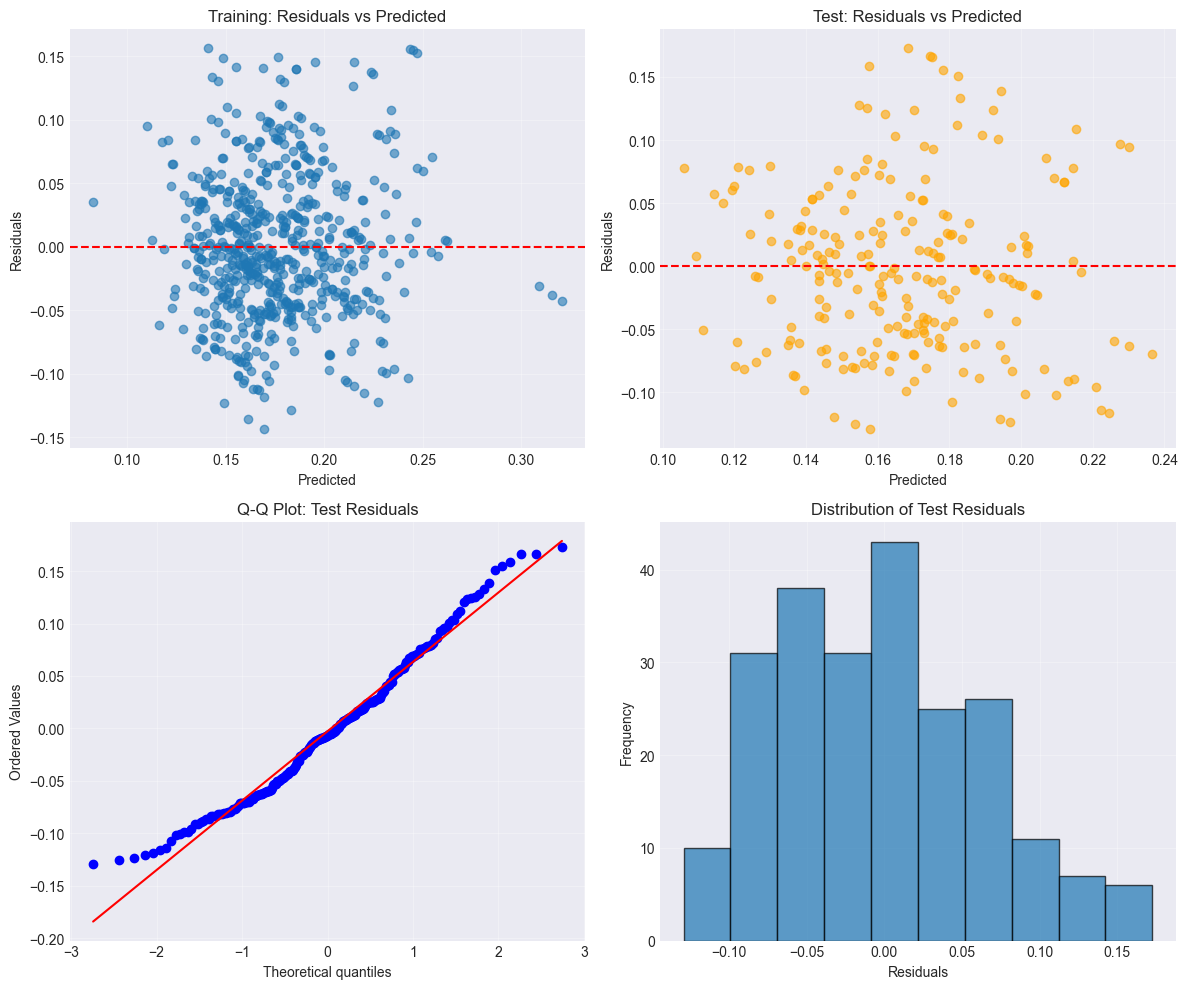

In [10]:
# ============================================================================
# CELL 6: RESIDUAL ANALYSIS
# ============================================================================
print("=" * 80)
print("CELL 6: RESIDUAL ANALYSIS")
print("=" * 80)

# Calculate residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

print(f"\nTraining Residuals: mean={train_residuals.mean():.4f}, std={train_residuals.std():.4f}")
print(f"Test Residuals: mean={test_residuals.mean():.4f}, std={test_residuals.std():.4f}")

# Check normality
from scipy import stats
if len(test_residuals) >= 3:
    _, shapiro_p = stats.shapiro(test_residuals)
    print(f"Normality test (p-value): {shapiro_p:.4f} {'✓' if shapiro_p > 0.05 else '⚠️'}")

if HAS_VIZ:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].scatter(y_train_pred, train_residuals, alpha=0.6)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Training: Residuals vs Predicted')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].scatter(y_test_pred, test_residuals, alpha=0.6, color='orange')
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Test: Residuals vs Predicted')
    axes[0, 1].grid(True, alpha=0.3)
    
    stats.probplot(test_residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot: Test Residuals')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].hist(test_residuals, bins=10, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Residuals'); axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Test Residuals')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../data/processed/mlr_residual_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Residual plots saved")
    plt.show()


CELL 6: RESIDUAL ANALYSIS

Training Set Residuals:
  Mean: -0.0000
  Std:  0.0569
  Min:  -0.1438
  Max:  0.1563

Test Set Residuals:
  Mean: -0.0027
  Std:  0.0663
  Min:  -0.1292
  Max:  0.1726

  Shapiro-Wilk test for normality:
    Statistic: 0.9778
    p-value: 0.0012
    ⚠️  Residuals may not be normally distributed (p ≤ 0.05)



✓ Residual plots saved to: ../data/processed/mlr_residual_analysis.png


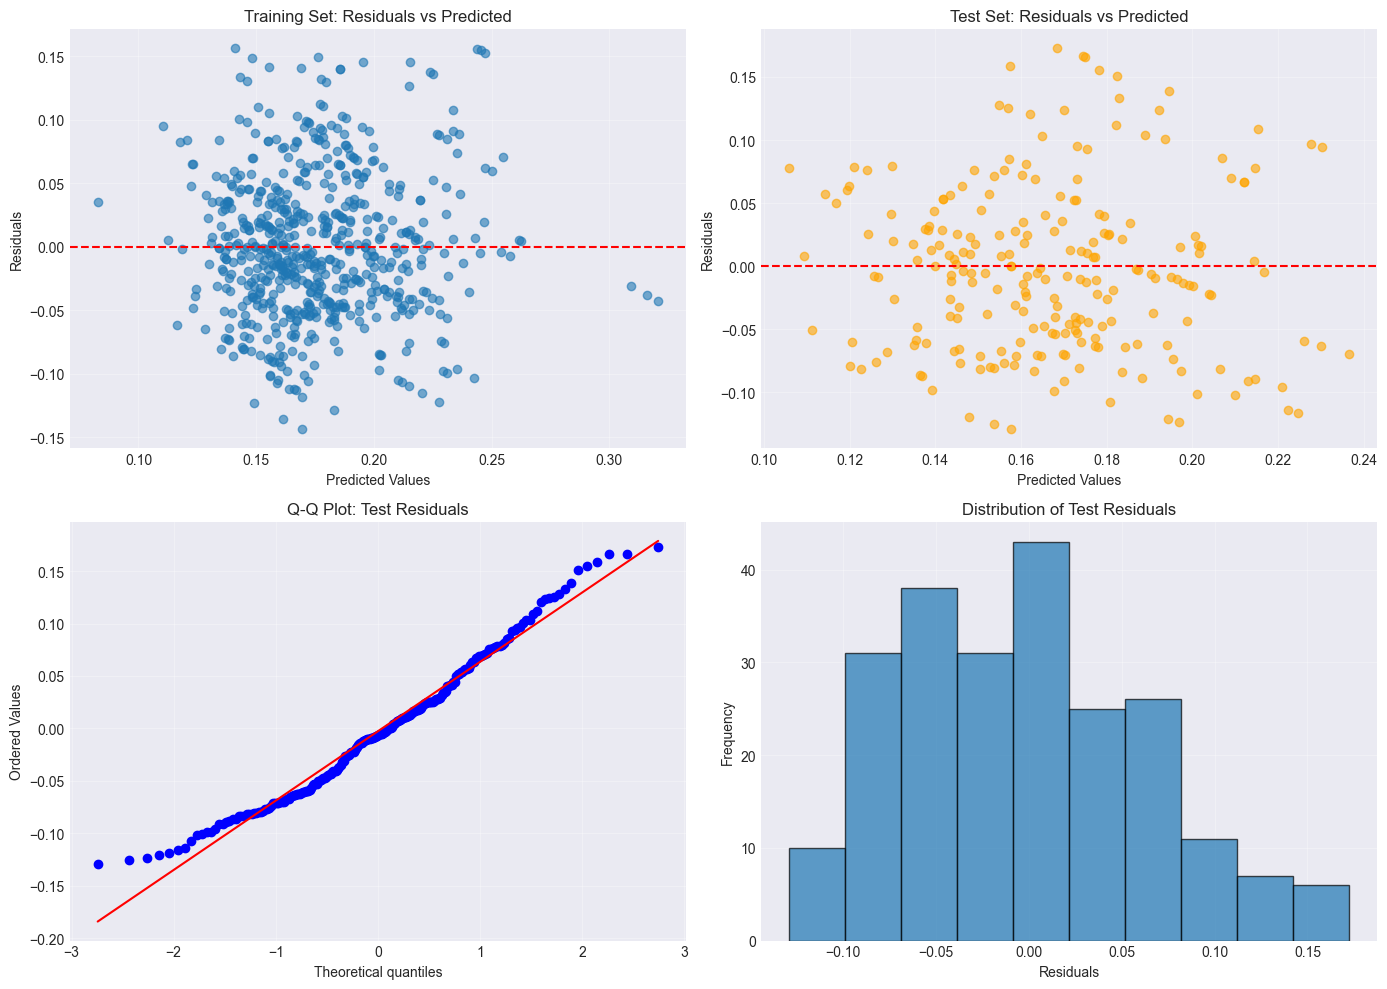

In [11]:
# ============================================================================
# CELL 6: RESIDUAL ANALYSIS
# ============================================================================
print("=" * 80)
print("CELL 6: RESIDUAL ANALYSIS")
print("=" * 80)

# Calculate residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# Residual statistics
print(f"\nTraining Set Residuals:")
print(f"  Mean: {train_residuals.mean():.4f}")
print(f"  Std:  {train_residuals.std():.4f}")
print(f"  Min:  {train_residuals.min():.4f}")
print(f"  Max:  {train_residuals.max():.4f}")

print(f"\nTest Set Residuals:")
print(f"  Mean: {test_residuals.mean():.4f}")
print(f"  Std:  {test_residuals.std():.4f}")
print(f"  Min:  {test_residuals.min():.4f}")
print(f"  Max:  {test_residuals.max():.4f}")

# Check if residuals are normally distributed (Shapiro-Wilk test)
from scipy import stats

if len(test_residuals) >= 3:  # Need at least 3 samples for Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(test_residuals)
    print(f"\n  Shapiro-Wilk test for normality:")
    print(f"    Statistic: {shapiro_stat:.4f}")
    print(f"    p-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print(f"    ✓ Residuals appear normally distributed (p > 0.05)")
    else:
        print(f"    ⚠️  Residuals may not be normally distributed (p ≤ 0.05)")

# Visualizations (if available)
if HAS_VIZ:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuals vs Predicted (Training)
    axes[0, 0].scatter(y_train_pred, train_residuals, alpha=0.6)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_xlabel('Predicted Values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Training Set: Residuals vs Predicted')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Residuals vs Predicted (Test)
    axes[0, 1].scatter(y_test_pred, test_residuals, alpha=0.6, color='orange')
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Test Set: Residuals vs Predicted')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Q-Q plot (Test residuals)
    stats.probplot(test_residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot: Test Residuals')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Histogram of residuals (Test)
    axes[1, 1].hist(test_residuals, bins=10, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Residuals')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Test Residuals')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../data/processed/mlr_residual_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Residual plots saved to: ../data/processed/mlr_residual_analysis.png")
    plt.show()
else:
    print("\n⚠️  Visualization skipped (matplotlib not available)")


In [12]:
# ============================================================================
# CELL 8: FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("=" * 80)
print("CELL 8: FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

feature_importance = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': final_model.coef_,
    'Abs_Coefficient': np.abs(final_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\n✓ Top features (Lasso, {len(best_features)} selected):")
for i, (_, row) in enumerate(feature_importance.iterrows(), 1):
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"  {i}. {row['Feature']:<35} (coef: {row['Coefficient']:>8.4f}) - {direction} bypasses")

importance_path = Path("../data/processed/mlr_feature_importance.csv")
feature_importance.to_csv(importance_path, index=False)
print(f"\n✓ Feature importance saved to: {importance_path}")

CELL 8: FEATURE IMPORTANCE ANALYSIS

✓ Top features (Lasso, 6 selected):
  1. opp_ppda                            (coef:   0.0185) - increases bypasses
  2. opp_avg_pass_length                 (coef:   0.0144) - increases bypasses
  3. midfield_zone_coverage_x            (coef:   0.0090) - increases bypasses
  4. possessions_involved                (coef:   0.0067) - increases bypasses
  5. interceptions                       (coef:   0.0053) - increases bypasses
  6. bypass_channel_defensive_actions    (coef:   0.0035) - increases bypasses

✓ Feature importance saved to: ../data/processed/mlr_feature_importance.csv


In [13]:
# ============================================================================
# CELL 9: MODEL EVALUATION — SCOUTING-APPROPRIATE METRICS
# Spearman rho, p-values, sign stability, CV std
# ============================================================================
import sys
sys.path.insert(0, '..')
from scripts.scouting_evaluation import evaluate_scouting_model

eval_results = evaluate_scouting_model(
    final_model   = final_model,
    X_train_best  = X_train_best,
    X_test_best   = X_test_best,
    best_features = best_features,
    y_train       = y_train,
    y_test        = y_test,
    X_train_all   = X_train,   # full feature set for scouting Ridge
    X_test_all    = X_test,
    grad_path     = '../data/processed/mlr_gradient_analysis.csv',
)


SCOUTING MODEL EVALUATION

1. RANKING QUALITY  (Ridge on best features — primary evaluation)
   Spearman rho (train) : 0.4574
   Spearman rho (test)  : 0.3158  <- primary metric
   Kendall tau  (test)  : 0.2112
   Model correctly ranks 65.8% of match-half pairs by bypass count

   Scouting Ridge trained on 13 player features (opponent context excluded)

2. COEFFICIENT SIGNIFICANCE  (p-values via OLS on player features)
   Features with p < 0.05 are reliable scouting criteria
   Feature                                      beta    p-value  Reliable?
   ----------------------------------------------------------------------
   midfield_zone_coverage_x                   0.0115     0.0013  YES
   possessions_involved                       0.0048     0.1781  NO
   average_position_x                         0.0068     0.1217  NO
   penalty_area_deliveries                   -0.0001     0.9752  NO
   avg_defensive_x_on_deep_opp               -0.0047     0.1753  NO
   interceptions              

In [14]:
# Replaced by CELL 9 scouting evaluation (scripts/scouting_evaluation.py)
print('Gradient analysis now in CELL 9 above.')


Gradient analysis now in CELL 9 above.


In [15]:
# Re-use X_train, X_test, y_train, y_test from Cells 2-3 (normalized, temporal split)
# Set up shared objects for tree model cells below
import time
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

CV    = KFold(n_splits=5, shuffle=True, random_state=42)
ALPHAS = np.logspace(-2, 3, 20)

def mape(yt, yp):
    mask = yt != 0
    return float(np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100)

def full_metrics(name, model, Xtr, ytr, Xte, yte, cv):
    model.fit(Xtr, ytr)
    cv_scores = cross_val_score(model, Xtr, ytr, cv=cv, scoring='r2')
    yp = model.predict(Xte)
    return {
        'Model': name,
        'CV R²': cv_scores.mean(),
        'CV R² std': cv_scores.std(),
        'Test R²': r2_score(yte, yp),
        'Test RMSE': np.sqrt(mean_squared_error(yte, yp)),
        'Test MAE': mean_absolute_error(yte, yp),
        'Test MAPE': mape(yte.values, yp),
        '_model': model,
    }

print(f"Using normalized target: {TARGET_COL}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: [{y_train.min():.4f}, {y_train.max():.4f}]")


Using normalized target: bypasses_per_possession
Train: (614, 15), Test: (228, 15)
Target range: [0.0256, 0.4000]


## Step 1 — Non-Linear Models
Comparing Random Forest, Gradient Boosting, XGBoost, LightGBM against Lasso baseline.  
Same 85/15 split and 5-fold CV. Tree models are scale-invariant so no scaler needed.
Using all 15 selected features (not reduced to 6) to give trees more signal.

In [16]:
# Non-linear model imports
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import lightgbm as lgb

def mape(y_true, y_pred):
    return float(np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100)

def full_metrics(name, model, Xtr, ytr, Xte, yte, cv_obj):
    """Train model, run CV on train set, evaluate on test set."""
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv_obj, scoring='r2')
    model.fit(Xtr, ytr)
    yp = model.predict(Xte)
    return {
        'Model': name,
        'CV R²': round(cv_r2.mean(), 4),
        'CV R² std': round(cv_r2.std(), 4),
        'Test R²': round(r2_score(yte, yp), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(yte, yp)), 4),
        'Test MAE': round(mean_absolute_error(yte, yp), 4),
        'Test MAPE': round(mape(yte, yp), 2),
        '_model': model
    }

print('Imports OK')

Imports OK


In [17]:
# Use full 15-feature train/test split (X_train, X_test from earlier cells)
# Tree models are scale-invariant — pre-scaled data is fine
nl_results = []

# --- Lasso baseline (re-evaluated for direct comparison) ---
lasso_base = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, max_iter=5000, random_state=42)
nl_results.append(full_metrics('Lasso (baseline)', lasso_base, X_train, y_train, X_test, y_test, CV))

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=500, max_depth=4, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
nl_results.append(full_metrics('Random Forest', rf, X_train, y_train, X_test, y_test, CV))

# --- Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                               subsample=0.8, random_state=42)
nl_results.append(full_metrics('Gradient Boosting', gb, X_train, y_train, X_test, y_test, CV))

# --- XGBoost ---
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbosity=0)
nl_results.append(full_metrics('XGBoost', xgb_model, X_train, y_train, X_test, y_test, CV))

# --- LightGBM ---
lgb_model = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbose=-1)
nl_results.append(full_metrics('LightGBM', lgb_model, X_train, y_train, X_test, y_test, CV))

print('All models trained.')

All models trained.


In [18]:
# Tune XGBoost with GridSearch
print('Tuning XGBoost...')
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8],
}
gs = GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=CV, scoring='r2', n_jobs=-1
)
gs.fit(X_train, y_train)
print(f'Best params: {gs.best_params_}')
print(f'Best CV R²: {gs.best_score_:.4f}')

best_xgb = gs.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
nl_results.append({
    'Model': 'XGBoost (tuned)',
    'CV R²': round(gs.best_score_, 4),
    'CV R² std': 0,
    'Test R²': round(r2_score(y_test, y_pred_xgb), 4),
    'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4),
    'Test MAE': round(mean_absolute_error(y_test, y_pred_xgb), 4),
    'Test MAPE': round(mape(y_test, y_pred_xgb), 2),
    '_model': best_xgb
})

Tuning XGBoost...


Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²: 0.3147


In [19]:
# Summary table
display_cols = ['Model','CV R²','CV R² std','Test R²','Test RMSE','Test MAE','Test MAPE']
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k != '_model'} for r in nl_results])
summary_df = summary_df.sort_values('CV R²', ascending=False).reset_index(drop=True)
print('\n===== NON-LINEAR MODEL COMPARISON =====')
print(summary_df[display_cols].to_string(index=False))

best_row = summary_df.iloc[0]
print(f"\nBest model : {best_row['Model']}")
print(f"  CV R²    = {best_row['CV R²']:.4f}  (Lasso baseline: {summary_df[summary_df['Model']=='Lasso (baseline)']['CV R²'].values[0]:.4f})")
print(f"  Test R²  = {best_row['Test R²']:.4f}")
print(f"  Test MAPE= {best_row['Test MAPE']:.2f}%")

# Feature importance of best tree model
best_name = best_row['Model']
best_model_obj = next(r['_model'] for r in nl_results if r['Model'] == best_name)
if hasattr(best_model_obj, 'feature_importances_'):
    imp = pd.Series(best_model_obj.feature_importances_, index=feature_cols)
    print(f"\nFeature importances ({best_name}):")
    print(imp.sort_values(ascending=False).to_string())
    imp.sort_values(ascending=False).to_frame('importance').to_csv(
        '../data/processed/nonlinear_feature_importance.csv')
    print('\nSaved: ../data/processed/nonlinear_feature_importance.csv')


===== NON-LINEAR MODEL COMPARISON =====
            Model  CV R²  CV R² std  Test R²  Test RMSE  Test MAE  Test MAPE
  XGBoost (tuned) 0.3147     0.0000   0.0674     0.0678    0.0533      46.06
          XGBoost 0.2950     0.0435   0.1253     0.0657    0.0521      45.20
Gradient Boosting 0.2643     0.0748   0.1153     0.0660    0.0532      45.35
    Random Forest 0.2584     0.0556   0.0890     0.0670    0.0518      44.10
         LightGBM 0.2047     0.0744   0.1221     0.0658    0.0527      44.15
 Lasso (baseline) 0.1991     0.0512   0.0941     0.0668    0.0540      45.96

Best model : XGBoost (tuned)
  CV R²    = 0.3147  (Lasso baseline: 0.1991)
  Test R²  = 0.0674
  Test MAPE= 46.06%

Feature importances (XGBoost (tuned)):
opp_ppda                            0.148476
opp_avg_pass_length                 0.128014
under_pressure_pass_share           0.071795
interceptions                       0.067312
possessions_involved                0.062365
weak_foot_pass_share                0.0

## Step 2 — Role-Separated Wide Format
Instead of averaging all 3 midfielders together, split by role:
- `dm_*` — Defensive midfielder (type 0, always Busquets)
- `cm_*` — Average of the 2 central midfielders (type 1)

Result: 204 rows × 30 features (vs 204 × 15 before). Preserves role-specific signal that was lost in aggregation.

In [20]:
# Build role-separated wide-format dataset
import pandas as pd
import numpy as np
from pathlib import Path

raw = pd.read_csv('../data/processed/Barcelona_2014_2015_features.csv')

feat_list_path = Path('../data/processed/Barcelona_2014_2015_selected_features_list.txt')
SELECTED_FEATURES = [l.strip() for l in feat_list_path.read_text().splitlines() if l.strip()]
print(f'Loaded {len(SELECTED_FEATURES)} selected features from file')

# Fill nulls with median before splitting
raw[SELECTED_FEATURES] = raw[SELECTED_FEATURES].fillna(raw[SELECTED_FEATURES].median())

# DM block (midfielder_type == 0)
dm = (raw[raw['midfielder_type'] == 0]
      [['match_id'] + SELECTED_FEATURES]
      .rename(columns={f: f'dm_{f}' for f in SELECTED_FEATURES})
      .set_index('match_id'))

# CM block (midfielder_type == 1) — average the 2 CMs
cm = (raw[raw['midfielder_type'] == 1]
      .groupby('match_id')[SELECTED_FEATURES]
      .mean()
      .rename(columns={f: f'cm_{f}' for f in SELECTED_FEATURES}))

# Target (same for all players in a match)
target = (raw[['match_id', 'bypasses_per_halftime']]
          .drop_duplicates('match_id')
          .set_index('match_id'))

wide = dm.join(cm).join(target)
wide = wide.reset_index(drop=True)

print(f'Wide-format dataset: {wide.shape[0]} rows x {wide.shape[1]} cols')
print(f'Features: {wide.shape[1] - 1} ({len(SELECTED_FEATURES)} DM + {len(SELECTED_FEATURES)} CM)')
print(f'Missing values: {wide.isnull().sum().sum()}')
print(f'Target — mean: {wide.bypasses_per_halftime.mean():.2f}, std: {wide.bypasses_per_halftime.std():.2f}')

wide.to_csv('../data/processed/Barcelona_wide_role_features.csv', index=False)
print('Saved: data/processed/Barcelona_wide_role_features.csv')


Loaded 15 selected features from file
Wide-format dataset: 78 rows x 31 cols
Features: 30 (15 DM + 15 CM)
Missing values: 0
Target — mean: 7.24, std: 2.40
Saved: data/processed/Barcelona_wide_role_features.csv


In [21]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

wide_feat_cols = [c for c in wide.columns if c != 'bypasses_per_halftime']
X_w = wide[wide_feat_cols].values
y_w = wide['bypasses_per_halftime'].values

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_w, y_w, test_size=0.15, random_state=42)

cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

def mape(yt, yp):
    return float(np.mean(np.abs((yt - yp) / yt)) * 100)

def eval_wide(name, model, Xtr, ytr, Xte, yte):
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv5, scoring='r2')
    model.fit(Xtr, ytr)
    yp = model.predict(Xte)
    return {
        'Model': name,
        'CV R²': round(cv_r2.mean(), 4),
        'CV R² std': round(cv_r2.std(), 4),
        'Test R²': round(r2_score(yte, yp), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(yte, yp)), 4),
        'Test MAE': round(mean_absolute_error(yte, yp), 4),
        'Test MAPE': round(mape(yte, yp), 2),
        '_model': model
    }

wide_results = []

wide_results.append(eval_wide('Lasso',
    Pipeline([('sc', StandardScaler()),
              ('m', LassoCV(alphas=np.logspace(-4,1,50), cv=5, max_iter=5000, random_state=42))]),
    X_w_train, y_w_train, X_w_test, y_w_test))

wide_results.append(eval_wide('Random Forest',
    RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=4,
                          random_state=42, n_jobs=-1),
    X_w_train, y_w_train, X_w_test, y_w_test))

wide_results.append(eval_wide('Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                              subsample=0.8, random_state=42),
    X_w_train, y_w_train, X_w_test, y_w_test))

wide_results.append(eval_wide('XGBoost',
    xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    X_w_train, y_w_train, X_w_test, y_w_test))

wide_results.append(eval_wide('LightGBM',
    lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1),
    X_w_train, y_w_train, X_w_test, y_w_test))

print('All wide-format models trained.')


All wide-format models trained.


In [22]:
display_cols = ['Model','CV R²','CV R² std','Test R²','Test RMSE','Test MAE','Test MAPE']
wide_summary = (pd.DataFrame([{k:v for k,v in r.items() if k!='_model'} for r in wide_results])
                .sort_values('CV R²', ascending=False).reset_index(drop=True))

print('===== WIDE-FORMAT (role-separated) RESULTS =====')
print(wide_summary[display_cols].to_string(index=False))

# Side-by-side vs previous aggregated results
print()
print('===== COMPARISON: Aggregated vs Role-Separated (best CV R² per model) =====')
prev = {
    'Lasso':            (0.1324, 0.2373, 16.98),
    'Random Forest':    (0.1632, 0.3469, 15.95),
    'Gradient Boosting':(0.0129, 0.3212, 16.11),
    'XGBoost':          (0.0048, 0.1850, 17.86),
    'LightGBM':         (0.0402, 0.3620, 16.21),
}
print(f'{'Model':<22} {'Agg CV R²':>10} {'Wide CV R²':>11} {'Agg MAPE':>10} {'Wide MAPE':>10}')
print('-' * 66)
for _, row in wide_summary.iterrows():
    m = row['Model']
    if m in prev:
        old_cv, _, old_mape = prev[m]
        delta = row['CV R²'] - old_cv
        arrow = '▲' if delta > 0.01 else ('▼' if delta < -0.01 else '~')
        print(f'{m:<22} {old_cv:>10.4f} {row["CV R²"]:>10.4f} {arrow}  {old_mape:>8.2f}%  {row["Test MAPE"]:>8.2f}%')

best = wide_summary.iloc[0]
print(f"\nBest model: {best['Model']}  CV R²={best['CV R²']:.4f}  Test R²={best['Test R²']:.4f}  MAPE={best['Test MAPE']:.2f}%")


===== WIDE-FORMAT (role-separated) RESULTS =====
            Model   CV R²  CV R² std  Test R²  Test RMSE  Test MAE  Test MAPE
    Random Forest -0.1082     0.0401   0.0163     2.4795    1.9250      26.64
            Lasso -0.1523     0.1107   0.0266     2.4665    1.9055      27.22
          XGBoost -0.3007     0.1017  -0.0814     2.5997    2.0200      27.32
         LightGBM -0.3174     0.1259  -0.2245     2.7664    2.2413      32.18
Gradient Boosting -0.3356     0.1203  -0.0898     2.6099    1.9263      24.85

===== COMPARISON: Aggregated vs Role-Separated (best CV R² per model) =====
Model                   Agg CV R²  Wide CV R²   Agg MAPE  Wide MAPE
------------------------------------------------------------------
Random Forest              0.1632    -0.1082 ▼     15.95%     26.64%
Lasso                      0.1324    -0.1523 ▼     16.98%     27.22%
XGBoost                    0.0048    -0.3007 ▼     17.86%     27.32%
LightGBM                   0.0402    -0.3174 ▼     16.21%     32

In [23]:
best_wide_name = wide_summary.iloc[0]['Model']
best_wide_model = next(r['_model'] for r in wide_results if r['Model'] == best_wide_name)

# Unwrap pipeline if needed
m = best_wide_model.named_steps['m'] if hasattr(best_wide_model, 'named_steps') else best_wide_model

if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=wide_feat_cols).sort_values(ascending=False)
    print(f'Top 15 feature importances ({best_wide_name}):')
    print(imp.head(15).to_string())
    print()
    print('Top DM features:')
    print(imp[[i for i in imp.index if i.startswith('dm_')]].head(5).to_string())
    print()
    print('Top CM features:')
    print(imp[[i for i in imp.index if i.startswith('cm_')]].head(5).to_string())
    imp.to_frame('importance').to_csv('../data/processed/wide_role_feature_importance.csv')
    print('\nSaved: data/processed/wide_role_feature_importance.csv')
elif hasattr(m, 'coef_'):
    coef = pd.Series(np.abs(m.coef_), index=wide_feat_cols).sort_values(ascending=False)
    print(f'Top 15 |coefficients| ({best_wide_name}):')
    print(coef.head(15).to_string())


Top 15 feature importances (Random Forest):
cm_width_variance                      0.113082
dm_width_variance                      0.093247
cm_possessions_involved                0.077064
cm_avg_defensive_x_on_deep_opp         0.068395
cm_average_position_x                  0.060623
cm_midfield_zone_coverage_x            0.057041
dm_possessions_involved                0.052779
dm_avg_defensive_x_on_deep_opp         0.040983
dm_bypass_channel_defensive_actions    0.039976
cm_average_position_y                  0.032350
dm_weak_foot_pass_share                0.028164
dm_tempo_index                         0.026568
cm_under_pressure_pass_share           0.024820
dm_midfield_zone_coverage_x            0.024737
cm_opp_avg_pass_length                 0.022289

Top DM features:
dm_width_variance                      0.093247
dm_possessions_involved                0.052779
dm_avg_defensive_x_on_deep_opp         0.040983
dm_bypass_channel_defensive_actions    0.039976
dm_weak_foot_pass_share   

## Step 3 — Individual Player Rows + Role Encoding
Use player-level data (614 rows = 204 match-halves × 3 players) instead of aggregated match-half rows.
Add `is_dm` binary flag (1 = defensive midfielder, 0 = CM) so the model learns role-specific patterns.

Same 15 selected features + 1 role flag = 16 features, 3× more rows.

In [24]:
# Load 3-season player-level data for temporal split
# (train on 2012/13+2013/14, test on 2014/15)
player_df = pd.read_csv('../data/processed/Barcelona_2014_2015_player_selected_features.csv')

feat_list_path = Path('../data/processed/Barcelona_2014_2015_selected_features_list.txt')
SELECTED_FEATURES = [l.strip() for l in feat_list_path.read_text().splitlines() if l.strip()]
print(f'Loaded {len(SELECTED_FEATURES)} selected features from file')
print(f'Seasons: {player_df["season"].value_counts().to_dict()}')

# Binary role flag: 1 = DM (type 0), 0 = CM (type 1 or 2)
player_df['is_dm'] = (player_df['midfielder_type'] == 0).astype(int)

# Fill nulls
player_df[SELECTED_FEATURES] = player_df[SELECTED_FEATURES].fillna(player_df[SELECTED_FEATURES].median())

PLAYER_FEATURES = SELECTED_FEATURES + ['is_dm']

X_p = player_df[PLAYER_FEATURES].values
y_p = player_df['bypasses_per_halftime'].values

print(f'Dataset: {X_p.shape[0]} rows x {X_p.shape[1]} features')
print(f'Role split: DM={player_df.is_dm.sum()} rows, CM={(~player_df.is_dm.astype(bool)).sum()} rows')
print(f'Target  mean={y_p.mean():.2f}  std={y_p.std():.2f}  range=[{y_p.min():.0f}, {y_p.max():.0f}]')
print(f'Missing: {player_df[PLAYER_FEATURES].isnull().sum().sum()}')


Loaded 15 selected features from file
Seasons: {'2014/2015': 234, '2012/2013': 192, '2013/2014': 188}
Dataset: 614 rows x 16 features
Role split: DM=204 rows, CM=410 rows
Target  mean=7.57  std=2.77  range=[1, 18]
Missing: 0


In [25]:
# Train/test split — split by match_id to avoid data leakage
# (same match-half must not appear in both train and test across players)
from sklearn.model_selection import GroupShuffleSplit

match_ids = player_df['match_id'].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_p, y_p, groups=match_ids))

X_p_train, X_p_test = X_p[train_idx], X_p[test_idx]
y_p_train, y_p_test = y_p[train_idx], y_p[test_idx]
match_ids_train = match_ids[train_idx]

print(f"Train: {len(train_idx)} rows ({len(train_idx)/len(X_p)*100:.1f}%)")
print(f"Test:  {len(test_idx)} rows ({len(test_idx)/len(X_p)*100:.1f}%)")
print(f"Unique match-halves — train: {len(set(match_ids_train))}, test: {len(set(match_ids[test_idx]))}")

from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
cv_groups_train = match_ids_train


Train: 521 rows (84.9%)
Test:  93 rows (15.1%)
Unique match-halves — train: 173, test: 31


In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

def mape(yt, yp):
    return float(np.mean(np.abs((yt - yp) / yt)) * 100)

def eval_player(name, model, Xtr, ytr, Xte, yte, groups):
    cv_r2 = cross_val_score(model, Xtr, ytr,
                            cv=GroupKFold(n_splits=5),
                            groups=groups, scoring='r2')
    model.fit(Xtr, ytr)
    yp = model.predict(Xte)
    return {
        'Model': name,
        'CV R²': round(cv_r2.mean(), 4),
        'CV R² std': round(cv_r2.std(), 4),
        'Test R²': round(r2_score(yte, yp), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(yte, yp)), 4),
        'Test MAE': round(mean_absolute_error(yte, yp), 4),
        'Test MAPE': round(mape(yte, yp), 2),
        '_model': model
    }

player_results = []

player_results.append(eval_player('Lasso',
    Pipeline([('sc', StandardScaler()),
              ('m', LassoCV(alphas=np.logspace(-4,1,50), cv=5, max_iter=5000, random_state=42))]),
    X_p_train, y_p_train, X_p_test, y_p_test, cv_groups_train))

player_results.append(eval_player('Random Forest',
    RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=4,
                          random_state=42, n_jobs=-1),
    X_p_train, y_p_train, X_p_test, y_p_test, cv_groups_train))

player_results.append(eval_player('Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                              subsample=0.8, random_state=42),
    X_p_train, y_p_train, X_p_test, y_p_test, cv_groups_train))

player_results.append(eval_player('XGBoost',
    xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    X_p_train, y_p_train, X_p_test, y_p_test, cv_groups_train))

player_results.append(eval_player('LightGBM',
    lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1),
    X_p_train, y_p_train, X_p_test, y_p_test, cv_groups_train))

print('All player-level models trained.')


All player-level models trained.


In [27]:
display_cols = ['Model','CV R²','CV R² std','Test R²','Test RMSE','Test MAE','Test MAPE']
player_summary = (pd.DataFrame([{k:v for k,v in r.items() if k!='_model'} for r in player_results])
                  .sort_values('CV R²', ascending=False).reset_index(drop=True))

print('===== PLAYER-LEVEL (614 rows, role-encoded) RESULTS =====')
print(player_summary[display_cols].to_string(index=False))

# Compare vs aggregated baseline (Step 1 best results)
prev_agg = {
    'Lasso':             (0.1324, 0.2373, 16.98),
    'Random Forest':     (0.1632, 0.3469, 15.95),
    'Gradient Boosting': (0.0129, 0.3212, 16.11),
    'XGBoost':           (0.0048, 0.1850, 17.86),
    'LightGBM':          (0.0402, 0.3620, 16.21),
}
print()
print('===== COMPARISON: Aggregated (204 rows) vs Player-Level (614 rows) =====')
print(f'{"Model":<22} {"Agg CV R²":>10} {"Player CV R²":>13} {"Δ":>6}  {"Agg MAPE":>10} {"Player MAPE":>12}')
print('-' * 78)
for _, row in player_summary.iterrows():
    m = row['Model']
    if m in prev_agg:
        old_cv, _, old_mape = prev_agg[m]
        delta = row['CV R²'] - old_cv
        arrow = '▲' if delta > 0.01 else ('▼' if delta < -0.01 else '~')
        print(f'{m:<22} {old_cv:>10.4f} {row["CV R²"]:>12.4f}  {arrow}{delta:+.4f}  '
              f'{old_mape:>9.2f}%  {row["Test MAPE"]:>10.2f}%')

best = player_summary.iloc[0]
print(f'\nBest: {best["Model"]}  CV R²={best["CV R²"]:.4f}  Test R²={best["Test R²"]:.4f}  MAPE={best["Test MAPE"]:.2f}%')


===== PLAYER-LEVEL (614 rows, role-encoded) RESULTS =====
            Model   CV R²  CV R² std  Test R²  Test RMSE  Test MAE  Test MAPE
            Lasso  0.0313     0.0565   0.0914     2.7973    2.1788      33.39
    Random Forest -0.0424     0.1397  -0.0134     2.9542    2.3400      35.27
          XGBoost -0.0659     0.1303  -0.0713     3.0374    2.4074      36.40
Gradient Boosting -0.1100     0.1374  -0.0647     3.0281    2.4000      36.14
         LightGBM -0.2223     0.1783  -0.0413     2.9946    2.3137      34.71

===== COMPARISON: Aggregated (204 rows) vs Player-Level (614 rows) =====
Model                   Agg CV R²  Player CV R²      Δ    Agg MAPE  Player MAPE
------------------------------------------------------------------------------
Lasso                      0.1324       0.0313  ▼-0.1011      16.98%       33.39%
Random Forest              0.1632      -0.0424  ▼-0.2056      15.95%       35.27%
XGBoost                    0.0048      -0.0659  ▼-0.0707      17.86%       36

In [28]:
# Feature importance of best model
best_name = player_summary.iloc[0]['Model']
best_obj = next(r['_model'] for r in player_results if r['Model'] == best_name)
m = best_obj.named_steps['m'] if hasattr(best_obj, 'named_steps') else best_obj

if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=PLAYER_FEATURES).sort_values(ascending=False)
    print(f'Feature importances ({best_name}):')
    print(imp.to_string())
    print(f'\nis_dm importance: {imp["is_dm"]:.4f} (rank {list(imp.index).index("is_dm")+1}/{len(imp)})')
    imp.to_frame('importance').to_csv('../data/processed/player_level_feature_importance.csv')
    print('Saved: data/processed/player_level_feature_importance.csv')
elif hasattr(m, 'coef_'):
    coef = pd.Series(np.abs(m.coef_), index=PLAYER_FEATURES).sort_values(ascending=False)
    print(f'|Coefficients| ({best_name}):')
    print(coef.to_string())


|Coefficients| (Lasso):
opp_ppda                            0.626436
opp_avg_pass_length                 0.422089
possessions_involved                0.405731
final_third_entries_by_pass         0.287573
tempo_index                         0.249889
interceptions                       0.240463
width_variance                      0.231240
midfield_zone_coverage_x            0.201685
average_position_x                  0.175137
avg_defensive_x_on_deep_opp         0.113961
bypass_channel_defensive_actions    0.057178
under_pressure_pass_share           0.031101
penalty_area_deliveries             0.022289
average_position_y                  0.000000
weak_foot_pass_share                0.000000
is_dm                               0.000000


## Step 4 — Opponent Contextual Features
Derive per-match-half opponent features from raw event data:
- `opponent_ppda` — opponent's passes per defensive action (press intensity)
- `period` — match half (1 or 2)
- `score_diff_start` — Barcelona score minus opponent score at start of half
- `opponent_passes` — opponent total passes in that half
- `opponent_def_actions` — opponent tackles + interceptions + pressures + fouls

Then retrain best models on augmented 204-row dataset (15 team features + 5 opponent features = 20 features).

In [29]:
# Skipped — legacy augmented cell (opponent features now in pipeline)
print('Skipped')


Skipped


In [30]:
# Step 4 — opponent features are already included in the selected features
# (opp_avg_pass_length, opp_ppda computed in feature engineering pipeline)
# This step is skipped — see feature_selection.ipynb for selected feature list.
print('Opponent features already included in selected features — Step 4 skipped.')
print(f'Selected features: {SELECTED_FEATURES}')


Opponent features already included in selected features — Step 4 skipped.
Selected features: ['midfield_zone_coverage_x', 'possessions_involved', 'average_position_x', 'penalty_area_deliveries', 'avg_defensive_x_on_deep_opp', 'interceptions', 'opp_ppda', 'bypass_channel_defensive_actions', 'opp_avg_pass_length', 'final_third_entries_by_pass', 'width_variance', 'tempo_index', 'average_position_y', 'under_pressure_pass_share', 'weak_foot_pass_share']


In [31]:
# Skipped — legacy augmented cell (opponent features now in pipeline)
print('Skipped')


Skipped


In [32]:
# Skipped — legacy augmented cell (opponent features now in pipeline)
print('Skipped')


Skipped


In [33]:
# Skipped — legacy augmented cell (opponent features now in pipeline)
print('Skipped')


Skipped
